# Plotting with Pandas


## Table of Contents
1. [Importing Libraries  and Open NYC Tree Data](#Importing-Libraries-and-Open-Data)  
2. [Initial data check and cleaning](#Initialdata-check-and-cleaning)
3. [Single Variable Visualization](#Single-variable-visualization)
4. [Two or More Variables Visualization](#Two-or-more-variables-visualization)

## Importing-libraries-and-open-data
The first thing we do when creating visualizations is to import the necessary packages and read in the dataset we will be working with.

In [3]:
# Importing packages
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# Read NYC tree data. I downloaded the tree data, which can be read directly from the links below.
# The documents on each dataset are also available from my website.
# You can read 2015 tree census data using pd.read_csv 
tree2015 = pd.read_csv('../05/data/2015_Street_Tree_Census.csv')
tree2005 = pd.read_csv('../05/data/2005_Street_Tree_Census.csv')                       
tree1995 = pd.read_csv('../05/data/1995_Street_Tree_Census.csv')


C:\Users\Wenge\AppData\Local\Temp\ipykernel_25412\244534258.py:5: DtypeWarning: Columns (37) have mixed types. Specify dtype option on import or set low_memory=False.
  tree2005 = pd.read_csv('../05/data/2005_Street_Tree_Census.csv')


## Initialdata-check-and-cleaning

### Initial-data-checking

In [5]:
tree2015.head(10)
tree2015.tail(10)

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
683778,200671,229928,09/03/2015,29,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3053200,New York,40.624296,-73.960344,9.952583e+05,166726.7165,44.0,532.0,3180008.0,3.067170e+09
683779,193070,210437,08/31/2015,27,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3054800,New York,40.609541,-73.945835,9.992893e+05,161353.2295,48.0,548.0,3183517.0,3.068100e+09
683780,195173,304371,09/01/2015,15,0,OnCurb,Alive,Fair,Platanus x acerifolia,London planetree,...,4016900,New York,40.746122,-73.913657,1.008175e+06,211120.9420,26.0,169.0,4000947.0,4.001290e+09
683781,155348,230784,08/18/2015,20,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,3051001,New York,40.645694,-73.958179,9.958556e+05,174522.7192,40.0,51001.0,3328218.0,3.051250e+09
683782,184210,504308,08/29/2015,3,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,2038100,New York,40.854570,-73.899192,1.012137e+06,250636.4824,15.0,381.0,2013548.0,2.031490e+09
683783,155433,217978,08/18/2015,25,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,3051900,New York,40.713211,-73.954944,9.967407e+05,199121.6363,34.0,519.0,3062513.0,3.023690e+09
683784,183795,348185,08/29/2015,7,0,OnCurb,Alive,Good,Cladrastis kentukea,Kentucky yellowwood,...,4070700,New York,40.715194,-73.856650,1.023989e+06,199873.6475,29.0,707.0,4075448.0,4.031810e+09
683785,166161,401670,08/22/2015,12,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,5020100,New York,40.620762,-74.136517,9.463514e+05,165466.0763,50.0,201.0,5011657.0,5.004080e+09
683786,184028,504204,08/29/2015,9,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,2023502,New York,40.850828,-73.903115,1.011054e+06,249271.9507,15.0,23502.0,2007757.0,2.028120e+09
683787,200607,306527,09/03/2015,23,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4134100,New York,40.732165,-73.787526,1.043136e+06,206095.5383,24.0,1341.0,4153657.0,4.071360e+09


In [ ]:
tree2015.info()

In [ ]:
# check the index 
tree2015.index

In [ ]:
#check the columns
tree2015.columns

In [ ]:
tree1995.columns

In [ ]:
tree2015.shape

In [ ]:
### Select subsets <a id=2.2></a>

In [ ]:
tree2015['borough']

In [ ]:
tree2015.loc[0:4]

In [ ]:
tree2015.iloc[0:4]

In [6]:
# Two ways to print selected columns and indices
#tree2015.loc[0:4].borough
tree2015.loc[0:4,'borough']

0      Queens
1      Queens
2    Brooklyn
3    Brooklyn
4    Brooklyn
Name: borough, dtype: object

In [ ]:
# Extract information for certain columns
tree2015[['tree_id', 'tree_dbh','spc_common','borough']]

In [8]:
# check tree dbh > 50 in 
tree2015[tree2015['tree_dbh'] > 50]['borough']
#tree2015[tree2015['tree_dbh'] > 50].borough

2405           Brooklyn
3738             Queens
4887      Staten Island
6724      Staten Island
10083             Bronx
              ...      
675265           Queens
677954           Queens
679894           Queens
681736           Queens
682788            Bronx
Name: borough, Length: 364, dtype: object

In [ ]:
tree2015[tree2015['tree_dbh'] > 50].spc_common
#tree2015[tree2015['tree_dbh'] > 50].size
#tree2015[tree2015['tree_dbh'] > 50].count()

In [ ]:
#the isin() conditional function returns a True for each row the values are in the provided list.
#To filter the rows based on such a function, use the conditional function inside the selection brackets [].
# find which trees in Mahanttan. 
#tree2015[tree2015['borough'].isin(['Manhattan'])].count()
tree2015[tree2015['borough'] == 'Manhattan'].count()
tree2015[ (tree2015['borough'] == 'Manhattan') & (tree2015['tree_dbh'] > 50) ]

In [ ]:
# Select specific rows  and columns
tree2015.loc[tree2015['tree_dbh'] > 50, 'spc_common']
tree2015.loc[0:4, 'spc_common']


In [9]:
# update the column value
#tree2015[tree2015.borocode ==5].borough
#tree2005[tree2005.borocode == 5].boroname
tree2005.loc[tree2005.borocode == 5, 'boroname'] = 'Staten Island'
tree2005[tree2005.borocode == 5].boroname

429490    Staten Island
429508    Staten Island
429574    Staten Island
429676    Staten Island
429872    Staten Island
              ...      
592367    Staten Island
592368    Staten Island
592369    Staten Island
592370    Staten Island
592371    Staten Island
Name: boroname, Length: 99701, dtype: object

## Single-variable-visualization

There are two types of variables we can visualize: **categorical** and **numerical** variables. 


**Categorical** variables are not numbers. They are variables such as specise name, borough name.  Numbers can also be encoded as categorical variables such as zipcode ("11360","11428","90210").

**Numerical** variables are numbers. They are variables such as tree dbh values 


### Categorical Variables <a id=3.1></a>

In [10]:
# Number of tree counts by species 
# treecounts = tree2015.groupby('spc_common').size()
tree2015.groupby('borough').size()

borough
Bronx             85203
Brooklyn         177293
Manhattan         65423
Queens           250551
Staten Island    105318
dtype: int64

In [ ]:
tree2015.groupby('borough').count()

In [ ]:
# Number of tree counts by species 
# treecounts = tree2015.groupby('spc_common').size()
#tree2015.groupby('borough').size()

tree2015.groupby('borough').count()

Pandas plotting functions:
- df.plot.area     
- df.plot.barh     
- df.plot.density  
- df.plot.hist     
- df.plot.line     
- df.plot.scatter
- df.plot.bar      
- df.plot.box      
- df.plot.hexbin   
- df.plot.kde      
- df.plot.pie

https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#visualization


<class 'pandas.core.series.Series'>


Text(0, 0.5, 'Tree Count')

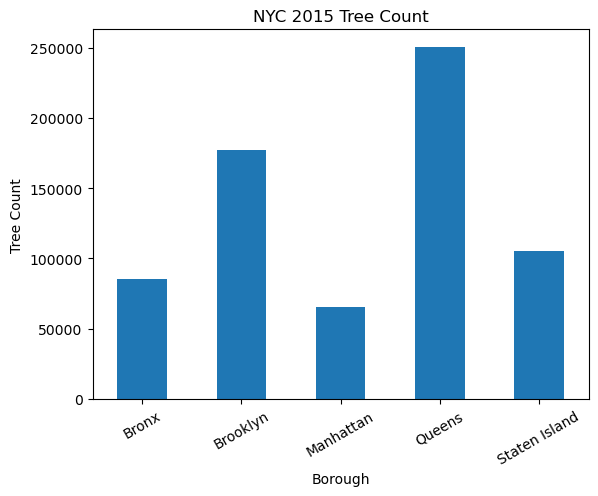

In [11]:
#plot a bar chart
#tree2015.groupby('borough').size().plot.bar(title = 'NYC 2015 Tree Count')
treecount_2015 = tree2015.groupby('borough').size()
print(type(treecount_2015))
treecount_2015.plot.bar(title = 'NYC 2015 Tree Count')
#treecount_2015.plot.barh(title = 'NYC 2015 Tree Count')
plt.xticks(rotation = 30, horizontalalignment = 'center') 
plt.xlabel('Borough')
plt.ylabel('Tree Count')


In [14]:
# create a df to include all tree counts
treecount = pd.DataFrame({
    '2015': tree2015.groupby('borough').size(),
    '2005': tree2005.groupby('boroname').size()}
)
treecount

,2015,2005
Bronx,85203,59925
Brooklyn,177293,142852
Manhattan,65423,49886
Queens,250551,240008
Staten Island,105318,99701


Text(0, 0.5, 'Tree Count')

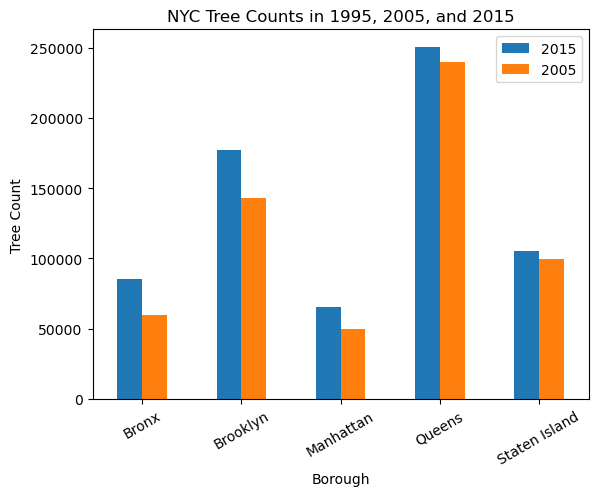

In [16]:
treecount.plot(kind = 'bar')
plt.xticks(rotation = 30, horizontalalignment = 'center')
plt.title('NYC Tree Counts in 1995, 2005, and 2015')
plt.xlabel('Borough')
plt.ylabel('Tree Count')

In [ ]:
treecount.plot(kind = 'bar', stacked = True)
plt.xticks(rotation = 30, horizontalalignment = 'center')
plt.title('NYC Tree Counts in 1995, 2005, and 2015')
plt.xlabel('Borough')
plt.ylabel('Tree Count')


In [ ]:
# horizontal bar 
tree2005.groupby('boroname').size().plot(kind = 'barh', title = 'NYC 2005 Tree Count')
#tree2005.groupby('boroname').size().plot.barh(title = 'NYC 2005 Tree Count')
plt.xticks(rotation = 30, horizontalalignment = 'center') 
plt.xlabel('Borough')
plt.ylabel('Tree Count')

### pie Graphs<a id=3.1.2></a>

In [ ]:
treecount.plot.pie(title = 'NYC Tree Count', legend=False, startangle=180,  autopct='%1.1f%%', subplots=True, figsize=(15,10))

<Axes: title={'center': 'NYC 2015 Tree Count'}>

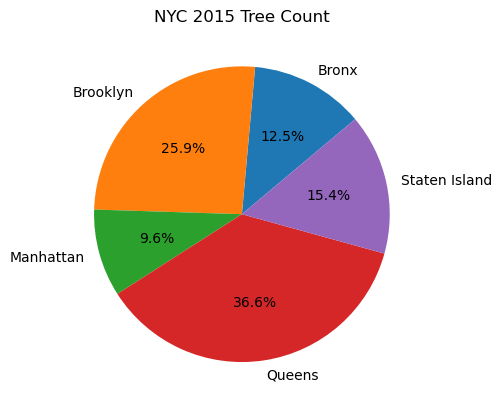

In [17]:
# pie chart
treecount2015 = tree2015.groupby('borough').size()
#treecount2015.plot.pie(y='Tree Count',title = 'NYC 2015 Tree Count', legend=False, startangle=180,  autopct='%1.1f%%')
treecount2015.plot.pie(y='Tree Count',title = 'NYC 2015 Tree Count', legend=False, startangle=40, autopct='%1.1f%%')

In [ ]:
treecount2015 = tree2015.groupby('spc_common').size()
print(treecount2015[0:10])
treecount2015_sorted = treecount2015.sort_values(ascending=False)
treecount2015_sorted[0:10]

In [ ]:
tree2015.groupby('spc_common').size().plot(kind = 'pie')


In [ ]:
# find the top 10 dominant species 
treecount2015 = tree2015.groupby('spc_common').size()
treecount2015_sorted = treecount2015.sort_values(ascending=False)
treecount2015_sorted[0:10]

In [ ]:
# pie chart for top ten dominant species 
treecount2015_sorted[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015')

### Line Graphs<a id=3.1.3></a>

In [ ]:
tree2015['tree_dbh'].plot()

### Numerical Variables <a id=3.2></a>

### Histogram <a id=3.2.1></a>
Pandas has multiple ways to do historgrams
1. pd.DataFrame.hist(column='your_data_column')
2. pd.DataFrame.plot(kind='hist')
3. pd.DataFrame.plot.hist()

In [ ]:
#tree2015.hist(column='tree_dbh', bins=200)
tree2015.hist('tree_dbh', bins=200,facecolor='c')

In [ ]:
tree2015['tree_dbh'].plot(kind='hist', bins=200)
#tree2015.plot(kind='hist, column='tree_dbh', bins=200)

In [ ]:
tree2015['tree_dbh'].plot.hist(bins=200)

In [ ]:
tree2015.plot.hist(bins=200)

In [ ]:
tree2015_dbh = tree2015[['tree_dbh','stump_diam']]
tree2015_dbh.plot.hist(bins=200)

In [ ]:
#tree2015.groupby(['spc_common'], sort=False).hist(column='tree_dbh', bins=200, figsize=(5,2)) 

In [ ]:
tree2015['tree_dbh'].hist(by=tree2015['spc_common'], figsize=(15,15))

### Density Plots <a id=3.2.2></a>

## Two-or-more-variables-visualization

### Categorical Variables <a id=3.1></a>

There are many visualization options for multiple categorical variables such as: **side by side graphs, grouped bar graphs, stacked bar graphs, mosaic plots, tree maps,** and **parallel sets**. 

### Numerical Variables 
see the air quality notebooks

### Time Series 

### Scatter plots 